# 13: two bases, h versus p refinement

Legendre (p-refinement, growing the polynomial degree) and block
(h-refinement, growing the window count) are two bases on the same image.
Claims:

1. On a globally smooth target, raising the coefficient count K under
   Legendre buys far more accuracy than raising K under block. On a step
   discontinuity block is exact when one of its window boundaries falls on
   the jump; when the jump falls inside a window neither basis wins and
   both errors fall slowly. False if the smooth ordering reverses at the
   largest K tried, if block's error on the aligned step is not 0, or if
   either basis leads the other by more than a factor of 2 at any K on the
   unaligned step.
2. Legendre's Gram matrix conditions worse as its order grows, and grows
   worse still off a uniform grid; block's stays close to flat because its
   windows do not overlap. False if block's condition number grows with
   order as fast as Legendre's, on any of the three grids.
3. Restricting a two-parameter linear fit to a basis's image costs
   precision only where the model does not already lie inside the span.
   A line lies in Legendre's span from the lowest order tried, so its
   efficiency should already sit at 1; block needs its window count to
   grow toward the sample count to approach the same efficiency. False if
   block's efficiency does not climb with order, or if Legendre's is
   below 1 anywhere in the range.


In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit.image import Image, Original
from dtfit_experimental.study import montecarlo, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

N = 200 if QUICK else 2000
KS = [8, 16] if QUICK else [8, 12, 16, 24, 32, 48, 64]
ORDERS = [4, 8, 16] if QUICK else [4, 6, 8, 12, 16, 24, 32, 48, 64, 96]
EFF_N = 50 if QUICK else 200
EFF_ORDERS = [4, 8, EFF_N] if QUICK else [4, 8, 16, 32, 64, EFF_N]
print(f"QUICK={QUICK} N={N} EFF_N={EFF_N}")

QUICK=False N=2000 EFF_N=200


## Reconstruction: error against coefficient count

`Image.of(Original(x, y), basis, k).reconstruct(x)` restricts the signal
to a K-dimensional image and reconstructs it on the same grid; the
statistic below is the RMSE of that reconstruction against the target.
Three targets: a smooth exponential, a step at 0.5, and a step at 1/pi.
Block splits [0, 1] into K equal windows, so 0.5 is a window boundary at
every even K and 1/pi is a boundary at none.


In [2]:
X = np.linspace(0.0, 1.0, N)
TARGETS = {"smooth": np.exp(-3.0 * X),
           "step_on_boundary": (X >= 0.5).astype(float),
           "step_off_boundary": (X >= 1.0 / np.pi).astype(float)}


def recon_rmse(y, basis, k):
    img = Image.of(Original(X, y), basis, k)
    return float(np.sqrt(np.mean((img.reconstruct(X) - y) ** 2)))


rows = []
for target, y in TARGETS.items():
    for basis in ("legendre", "block"):
        for k in KS:
            rows.append({"target": target, "basis": basis, "K": k,
                         "rmse": recon_rmse(y, basis, k)})
reconstruction = pd.DataFrame(rows)
reconstruction

,target,basis,K,rmse
0,smooth,legendre,8,6.068559e-08
1,smooth,legendre,12,1.107538e-12
2,smooth,legendre,16,4.626269e-16
3,smooth,legendre,24,6.935341e-16
4,smooth,legendre,32,7.062226e-16
5,smooth,legendre,48,4.980735e-16
6,smooth,legendre,64,5.440284e-16
7,smooth,block,8,4.387567e-02
8,smooth,block,12,2.938460e-02
9,smooth,block,16,2.205238e-02


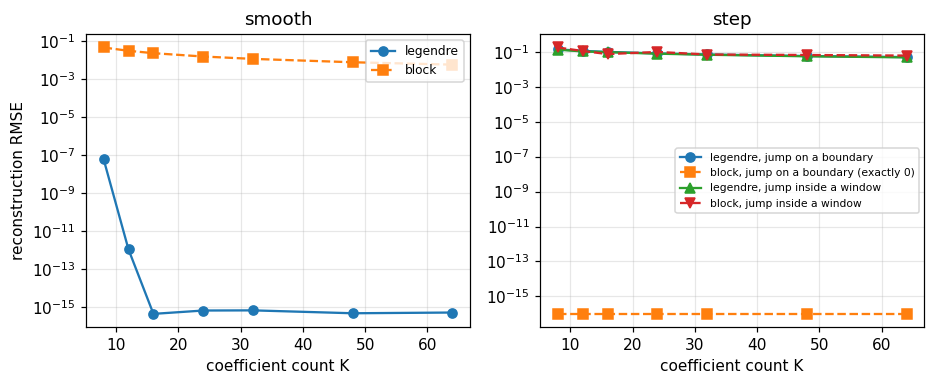

In [3]:
# the log axis cannot draw an exact zero; the floor is a drawing device
# and the legend says which series is exactly 0
PLOT_FLOOR = 1e-16

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.6))
smooth = reconstruction[reconstruction.target == "smooth"]
for basis, style in (("legendre", "o-"), ("block", "s--")):
    line = smooth[smooth.basis == basis].sort_values("K")
    ax1.semilogy(line.K, line.rmse.clip(lower=PLOT_FLOOR), style, label=basis)
ax1.set_title("smooth")
ax1.set_ylabel("reconstruction RMSE")
ax1.legend(loc="upper right", fontsize=8)

styles = {("step_on_boundary", "legendre"): ("o-", "legendre, jump on a boundary"),
          ("step_on_boundary", "block"): ("s--", "block, jump on a boundary (exactly 0)"),
          ("step_off_boundary", "legendre"): ("^-", "legendre, jump inside a window"),
          ("step_off_boundary", "block"): ("v--", "block, jump inside a window")}
for (target, basis), (style, label) in styles.items():
    line = reconstruction[(reconstruction.target == target)
                          & (reconstruction.basis == basis)].sort_values("K")
    ax2.semilogy(line.K, line.rmse.clip(lower=PLOT_FLOOR), style, label=label)
ax2.set_title("step")
ax2.legend(loc="center right", fontsize=7)

for ax in (ax1, ax2):
    ax.set_xlabel("coefficient count K")
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

Block is exact on the step at 0.5 only because a window boundary falls on
the jump. Move the jump to 1/pi and that advantage is gone: the two bases
then fall at the same slow rate and trade places with where the jump lands
inside its window. What block buys on a discontinuity is the freedom to
place a boundary on it, nothing more; where a boundary cannot be placed on
the jump the two bases are at parity. Notebook 18 measures that placement,
on known and on detected epochs.


In [4]:
last_k = KS[-1]
smooth_last = reconstruction[(reconstruction.target == "smooth")
                             & (reconstruction.K == last_k)].set_index("basis").rmse
on_block = reconstruction[(reconstruction.target == "step_on_boundary")
                          & (reconstruction.basis == "block")].rmse
off = reconstruction[reconstruction.target == "step_off_boundary"]
off_ratio = (off[off.basis == "legendre"].sort_values("K").rmse.to_numpy()
             / off[off.basis == "block"].sort_values("K").rmse.to_numpy())
# fails if legendre does not win the smooth target at the largest K
assert smooth_last["legendre"] < smooth_last["block"]
# fails if block is not exact on the step aligned to its boundaries
assert (on_block == 0.0).all()
# fails if either basis leads the other by more than 2x off the boundaries
assert ((off_ratio > 0.5) & (off_ratio < 2.0)).all()
print(f"at K={last_k}: legendre wins smooth ({smooth_last['legendre']:.2e} < "
      f"{smooth_last['block']:.2e}); block is exact on the aligned step at "
      f"every K; off the boundaries legendre/block stays in "
      f"[{off_ratio.min():.2f}, {off_ratio.max():.2f}]")

at K=64: legendre wins smooth (5.44e-16 < 5.53e-03); block is exact on the aligned step at every K; off the boundaries legendre/block stays in [0.75, 1.29]


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("13_two_bases", "reconstruction_rmse", reconstruction)
    print("wrote experiments/results/13_two_bases/reconstruction_rmse.csv")

wrote experiments/results/13_two_bases/reconstruction_rmse.csv


## Conditioning: the Gram matrix by order and grid

The image's Gram matrix `Phi^T Phi` (here read off `Image.G`, which does
not depend on the target values) conditions the least-squares solve.
Legendre's columns are polynomials on a shared domain and start to overlap
as the order grows; block's are disjoint window indicators, so its Gram
matrix stays close to diagonal regardless of order. `montecarlo.grid`
gives the three grid shapes to check that against.


In [6]:
def gram_cond(x, basis, order):
    y = np.exp(-3.0 * x)  # the Gram matrix does not depend on the target
    return float(np.linalg.cond(Image.of(Original(x, y), basis, order).G))


rows = []
for kind in ("uniform", "clustered", "random"):
    rng = np.random.default_rng(0)
    x = montecarlo.grid(kind, N, rng=rng)
    for basis in ("legendre", "block"):
        for order in ORDERS:
            rows.append({"grid": kind, "basis": basis, "order": order,
                         "cond": gram_cond(x, basis, order)})
conditioning = pd.DataFrame(rows)
conditioning.pivot_table(index=["grid", "order"], columns="basis", values="cond")

basis                block       legendre
grid      order                          
clustered 4       3.753472      14.782743
          6       4.510870      22.176278
          8       4.345324      31.240691
          12      4.857143      47.135676
          16      5.250000      63.837570
          24      5.380952      94.353615
          32      7.681818     125.926188
          48      7.866667     226.769489
          64      9.100000    1631.247903
          96     10.000000  374762.156294
random    4       1.064449       8.699454
          6       1.062696      13.081712
          8       1.126582      17.185713
          12      1.186667      25.274979
          16      1.327273      34.520496
          24      1.522388      53.525146
          32      1.620000      66.887319
          48      1.966667     120.625847
          64      2.473684     288.548144
          96      2.583333   12403.129206
uniform   4       1.000000       8.964264
          6       1.003003      12.923502
          8       1.000000      16.869244
          12      1.006024      24.730049
          16      1.000000      32.571067
          24      1.012048      48.285182
          32      1.016129      64.103521
          48      1.024390      95.975034
          64      1.032258     128.015516
          96      1.050000     193.611367

In [7]:
first_order, last_order = ORDERS[0], ORDERS[-1]
for kind in ("uniform", "clustered", "random"):
    sub = conditioning[conditioning.grid == kind]
    leg = sub[sub.basis == "legendre"].set_index("order").cond
    blk = sub[sub.basis == "block"].set_index("order").cond
    leg_growth = leg[last_order] / leg[first_order]
    blk_growth = blk[last_order] / blk[first_order]
    # fails if block's condition number grows with order as fast as legendre's
    assert leg_growth > blk_growth, kind
    print(f"{kind}: legendre condition grows {leg_growth:.1f}x from order "
          f"{first_order} to {last_order}, block grows {blk_growth:.1f}x")

uniform: legendre condition grows 21.6x from order 4 to 96, block grows 1.1x
clustered: legendre condition grows 25351.3x from order 4 to 96, block grows 2.7x
random: legendre condition grows 1425.7x from order 4 to 96, block grows 2.4x


In [8]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("13_two_bases", "gram_condition", conditioning)
    print("wrote experiments/results/13_two_bases/gram_condition.csv")

wrote experiments/results/13_two_bases/gram_condition.csv


## Efficiency: what the restriction costs a two-parameter fit

`montecarlo.image_efficiency` compares the restricted estimator's
asymptotic variance against the unrestricted pointwise fit, for a model's
Jacobian. A straight line (intercept and slope) is a two-parameter model
whose Jacobian is `[1, x]`; it already lies inside Legendre's span at any
order at least 1, so its restriction should cost nothing. Block windows
each carry their own local mean and only approach the same precision as
their count approaches the sample count.


In [9]:
EFF_X = np.linspace(0.0, 1.0, EFF_N)
EFF_JAC = np.stack([np.ones(EFF_N), EFF_X], axis=1)

rows = []
for basis in ("legendre", "block"):
    for order in EFF_ORDERS:
        eff = montecarlo.image_efficiency(EFF_JAC, EFF_X, basis=basis, order=order)
        rows.append({"basis": basis, "order": order,
                     "ratio_const": eff.ratio[0], "ratio_slope": eff.ratio[1]})
efficiency = pd.DataFrame(rows)
efficiency

,basis,order,ratio_const,ratio_slope
0,legendre,4,1.000000,1.000000
1,legendre,8,1.000000,1.000000
2,legendre,16,1.000000,1.000000
3,legendre,32,1.000000,1.000000
4,legendre,64,1.000000,1.000000
5,legendre,200,1.000000,1.000000
6,block,4,0.952513,0.937523
7,block,8,0.988283,0.984400
8,block,16,0.997079,0.996100
9,block,32,0.999277,0.999034


In [10]:
legendre_eff = efficiency[efficiency.basis == "legendre"]
block_eff = efficiency[efficiency.basis == "block"].sort_values("order")
# fails if legendre loses precision anywhere in the range tried
assert (legendre_eff.ratio_const > 0.999).all()
assert (legendre_eff.ratio_slope > 0.999).all()
# fails if block's efficiency does not climb toward 1 as its order grows
assert block_eff.ratio_slope.is_monotonic_increasing
assert block_eff.ratio_slope.iloc[-1] > 0.999
print("legendre already spans the line at every order tried; "
      f"block reaches {block_eff.ratio_slope.iloc[-1]:.4f} at order "
      f"{block_eff.order.iloc[-1]} (from {block_eff.ratio_slope.iloc[0]:.4f} "
      f"at order {block_eff.order.iloc[0]})")

legendre already spans the line at every order tried; block reaches 1.0000 at order 200 (from 0.9375 at order 4)


## Findings and limits

Legendre wins the smooth target outright. At K=16 its RMSE is 4.6e-16,
machine precision; block is at 2.2e-2 there and still at 5.5e-3 at K=64.

Block reconstructs the step at 0.5 exactly: RMSE 0.0 at every K tried.
The jump is a window boundary at each of them.

With the jump at 1/pi neither basis wins. Legendre falls from 0.132 to
0.048 across K=8 to K=64, block from 0.176 to 0.061, and the ratio of the
two stays in [0.75, 1.29]. Which of them leads changes with where the jump
lands inside its window. That is parity, and it is reported as parity.

A Legendre coefficient buys global smoothness, a block coefficient buys
locality. On a discontinuity the block basis buys one thing: a boundary
placed on the jump.

Block's Gram matrix condition number never exceeds 10.0 (clustered grid,
order 96). Legendre's reaches 194 on the uniform grid at order 96 and
374762 on the clustered one. From order 4 to order 96 Legendre grows
21.6x on the uniform grid, 1425.7x on the random one and 25351.3x on the
clustered one; block grows 1.1x, 2.4x and 2.7x. The growth rate is where
the two bases differ, not the conditioning at any single order.

Legendre's efficiency on the line is 1 for both the intercept and the
slope at every order from 4 to 200. Block starts at 0.9375 on the slope at
order 4 and reaches 1.0000 only at order 200, where its window count
equals the sample count. That is the cost of h-refinement, which the
reconstruction section does not show.

Limits: three synthetic targets, and the two steps differ only in where
the jump sits; the conditioning and efficiency sections use one linear
model on synthetic grids, not a real dataset. The three grid shapes are
`montecarlo.grid`'s own constructions, not sampling patterns measured from
an instrument. Robustness to outliers is out of scope here (notebook 14).


In [11]:
print(notebook.provenance(STARTED))

2026-09-21 commit 307f7bb dtfit 0.4.0 dtfit-experimental 0.1.0 0.3s
